# Signal Processing tookit trial

** It seems spkit ScalogramCWT is NOT good at plot bird/insect sound**

[Spkit github](https://github.com/Nikeshbajaj/spkit)

[Spkit document](https://spkit.readthedocs.io/en/latest/)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import spkit
print('spkit-version ', spkit.__version__)
from spkit.core.cwt import ScalogramCWT
from spkit.core.cwt import compare_cwt_example

install cvxpy for L1 norm minimization for PeriodStrength fun (Ramanujan methods)
spkit-version  0.0.9.4


## Load data

shape  (2048,) (2048,)


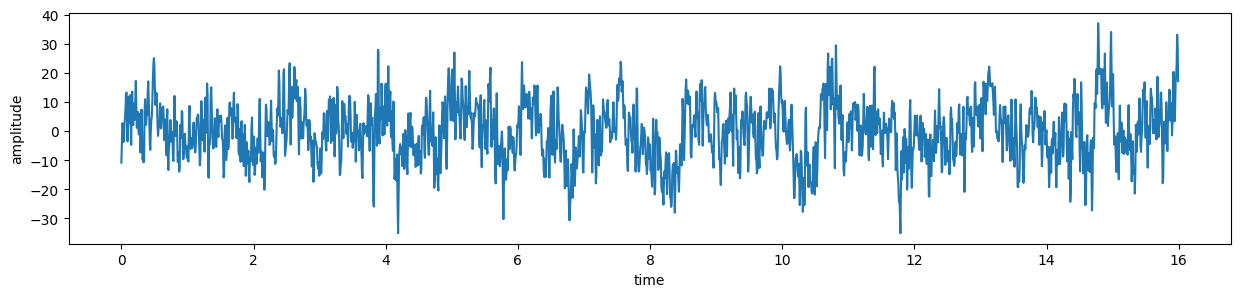

In [2]:
x,fs = spkit.load_data.eegSample_1ch()
t = np.arange(len(x))/fs

print('shape ',x.shape, t.shape)

plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlabel('time')
plt.ylabel('amplitude')
plt.show()

## Predefined example script

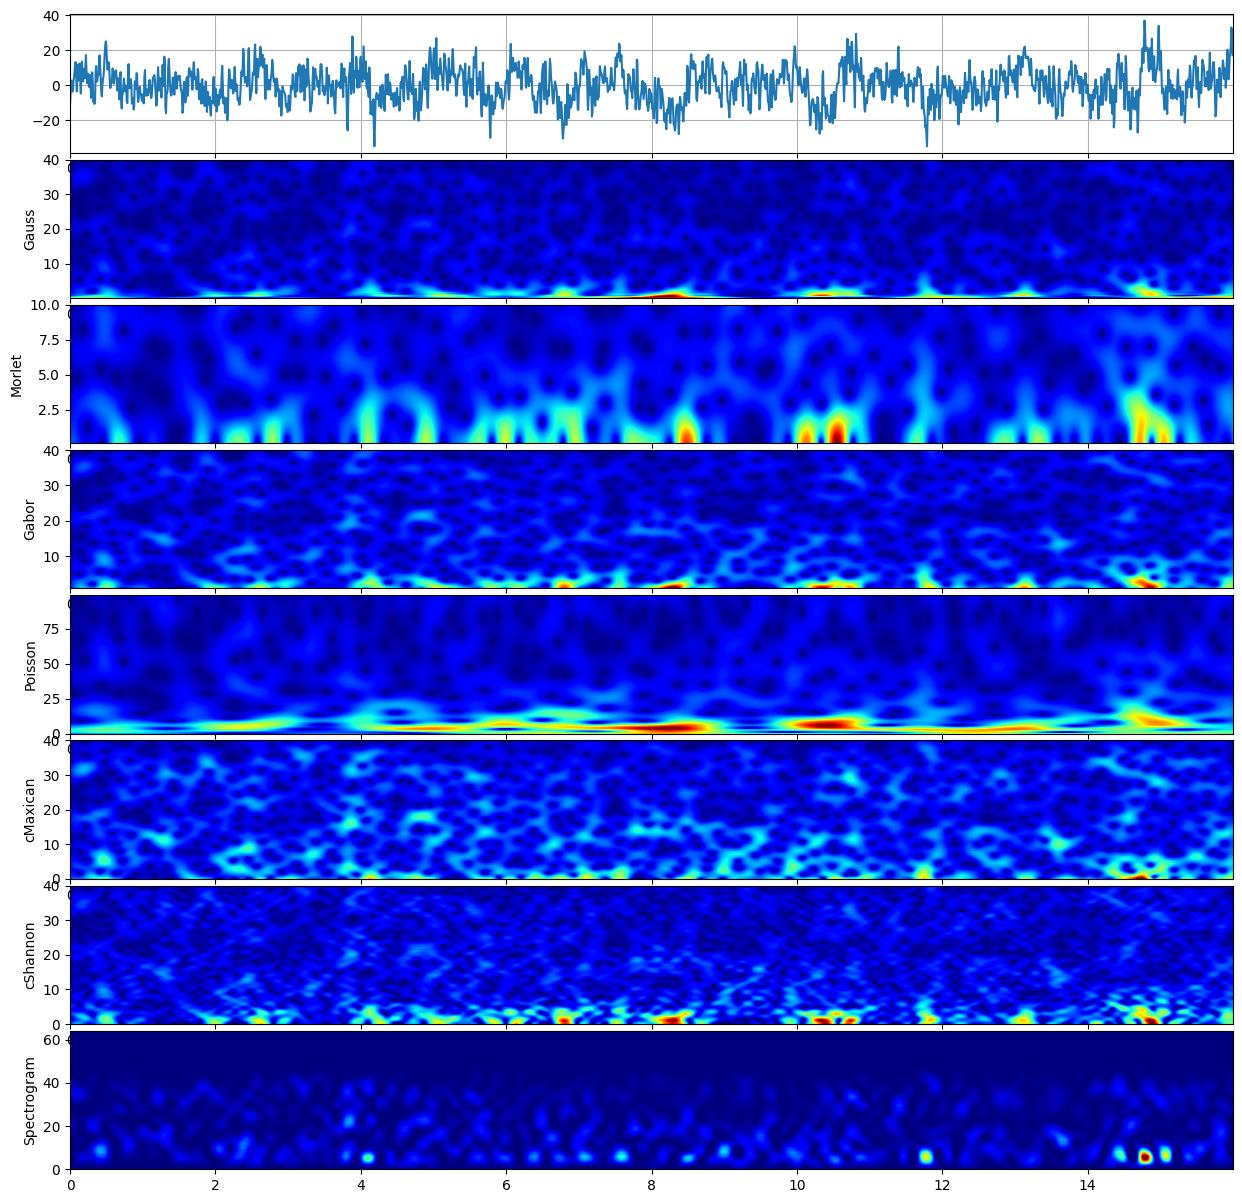

In [3]:
compare_cwt_example(x,t,fs=fs)

## Gauss wavelet

### Default parameter setting

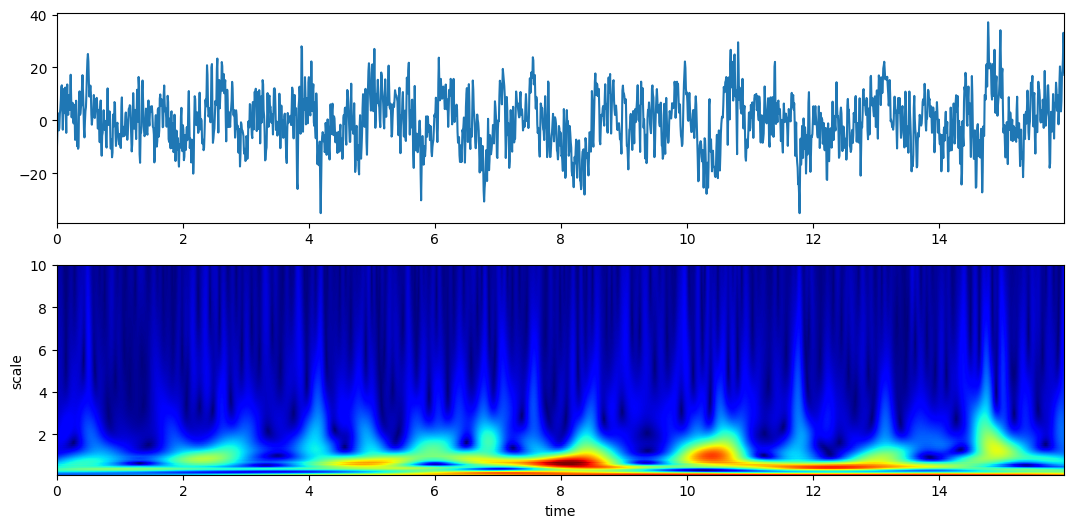

In [4]:
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True)

In [5]:
XW.shape, S.shape

((100, 2048), (100,))

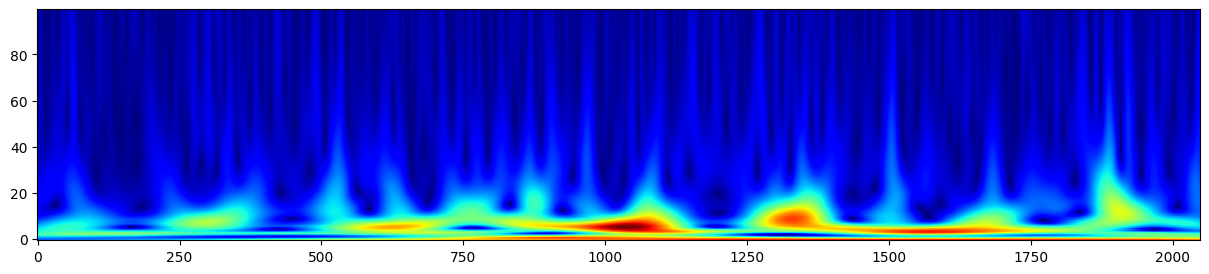

In [6]:
plt.figure(figsize=(15,3))
plt.imshow(np.abs(XW),aspect='auto',origin='lower',cmap='jet',interpolation='sinc')
plt.show()

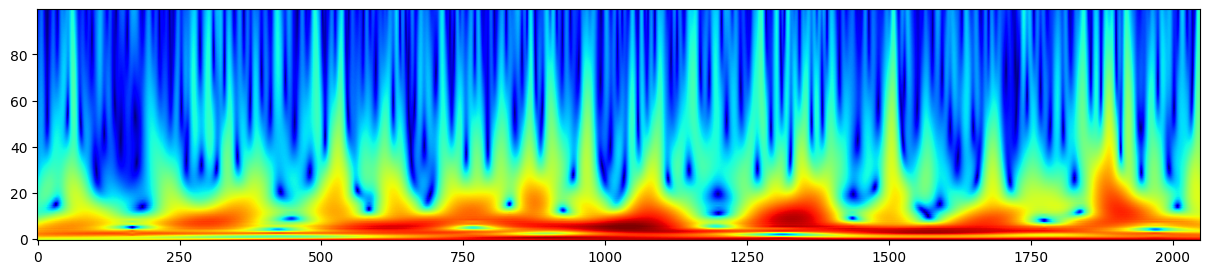

In [7]:
plt.figure(figsize=(15,3))
plt.imshow(np.log10(np.abs(XW)+0.2),aspect='auto',origin='lower',cmap='jet',interpolation='sinc')
plt.show()

### with custom setting

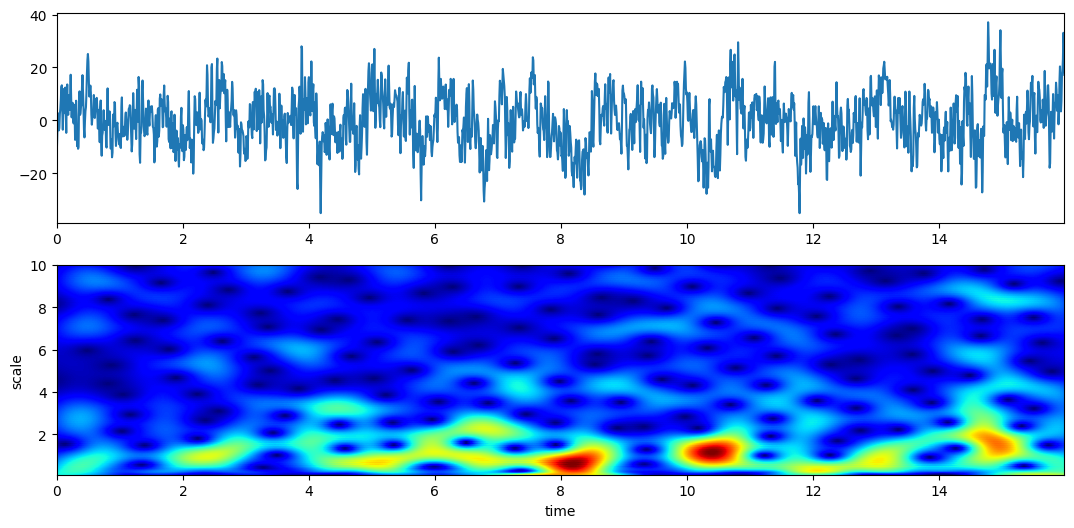

In [8]:
f0 = np.linspace(0.1,10,100)
Q  = np.linspace(0.1,5,100)
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True,f0=f0,Q=Q)

## Show wavelets in tim eand frequency domain

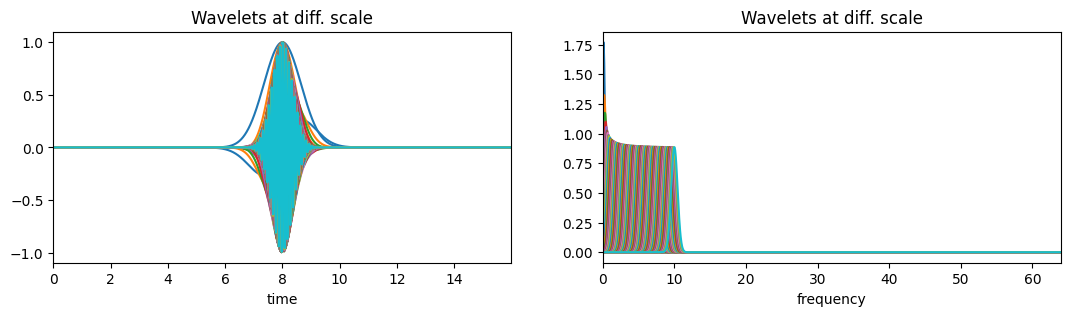

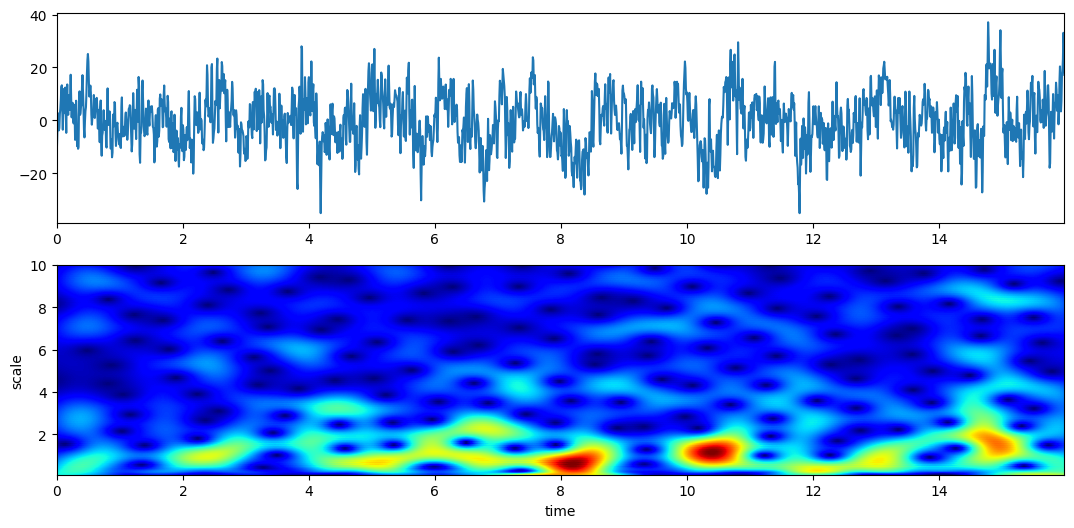

In [9]:
f0 = np.linspace(0.1,10,100)
Q  = np.linspace(0.1,5,100)
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True,PlotW=True,f0=f0,Q=Q)

## Other wavelets

Morlet wavelet


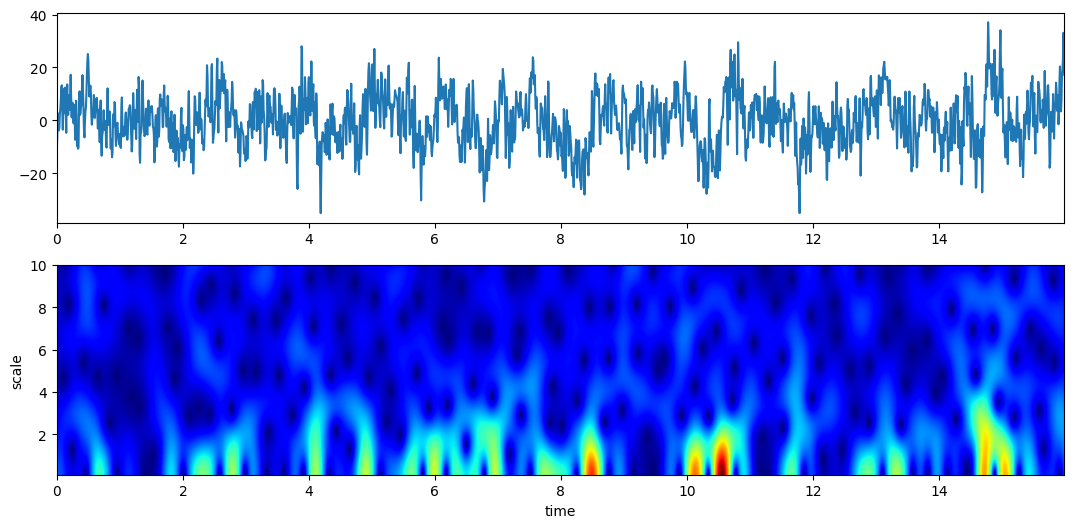

Gabor wavelet


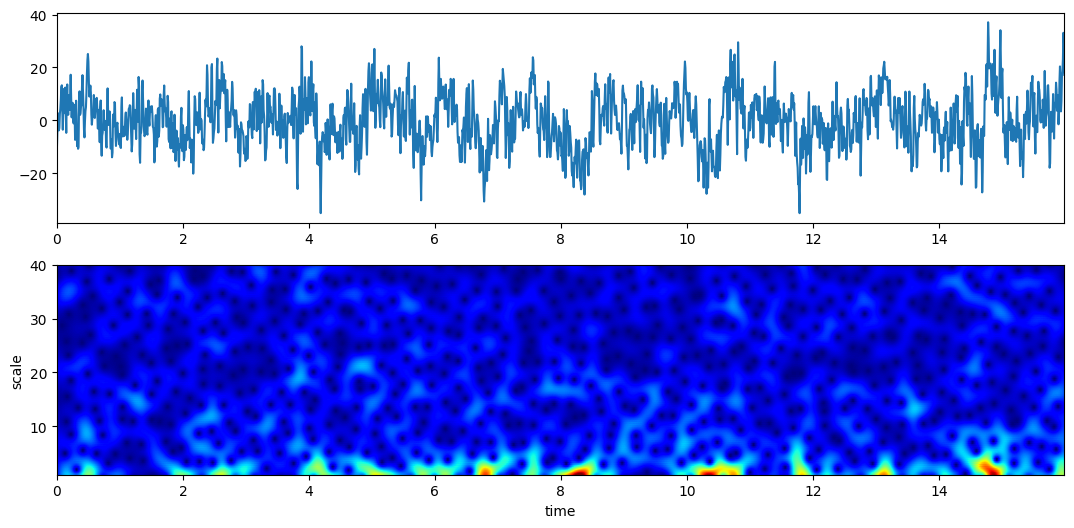

Poisson wavelet


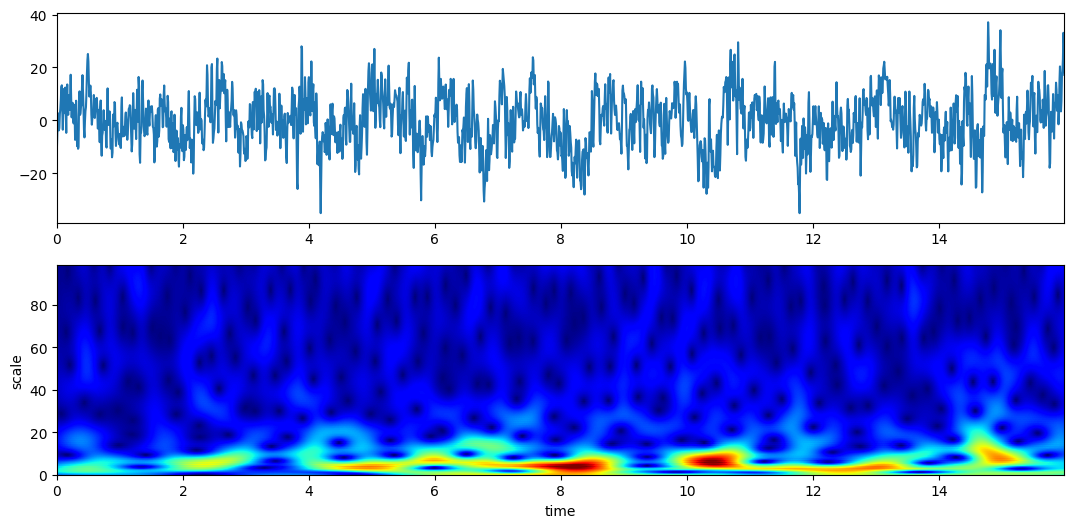

Complex Maxican wavelet


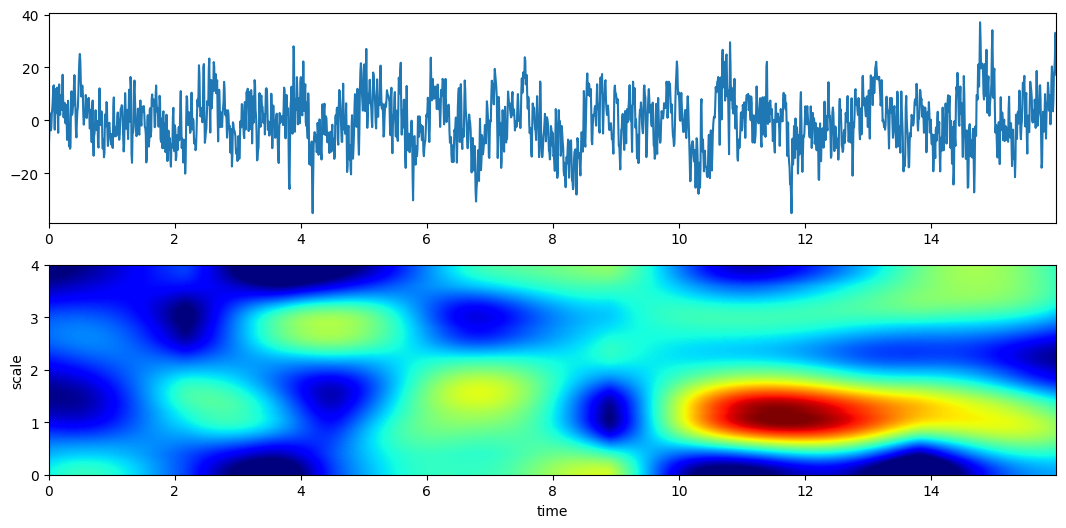

Complex Shannon wavelet


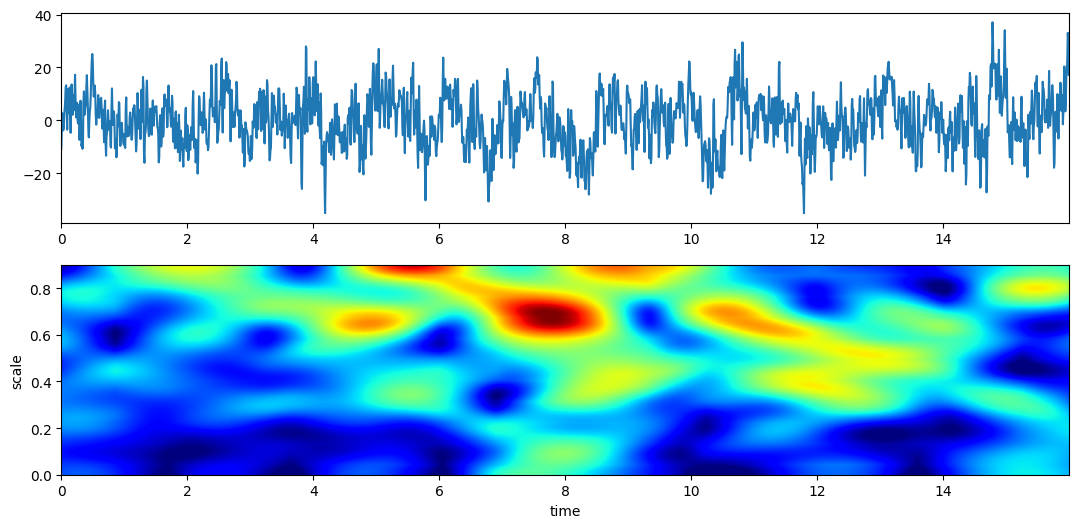

In [10]:
print('Morlet wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Morlet',PlotPSD=True,)

print('Gabor wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gabor',PlotPSD=True,)

print('Poisson wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Poisson',PlotPSD=True,)

print('Complex Maxican wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='cMaxican',PlotPSD=True,)

print('Complex Shannon wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='cShannon',PlotPSD=True,)

## Independent Component Analysis - ICA

In [2]:
from spkit import ICA

X,ch_names = spkit.load_data.eegSample()
nC =  len(ch_names)
print(f'num of channels: {nC}')
print(f'channel names: {ch_names}')
print(f'data shape {X.shape}')
# print(f'data:\n{X[:20]}')

x = X[128*10:128*12,:]
t = np.arange(x.shape[0])/128.0


num of channels: 14
channel names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
data shape (2048, 14)


In [ ]:

ica = ICA(n_components=nC,method='fastica')
ica.fit(x.T)
s1 = ica.transform(x.T)

ica = ICA(n_components=nC,method='infomax')
ica.fit(x.T)
s2 = ica.transform(x.T)

ica = ICA(n_components=nC,method='picard')
ica.fit(x.T)
s3 = ica.transform(x.T)

ica = ICA(n_components=nC,method='extended-infomax')
ica.fit(x.T)
s4 = ica.transform(x.T)


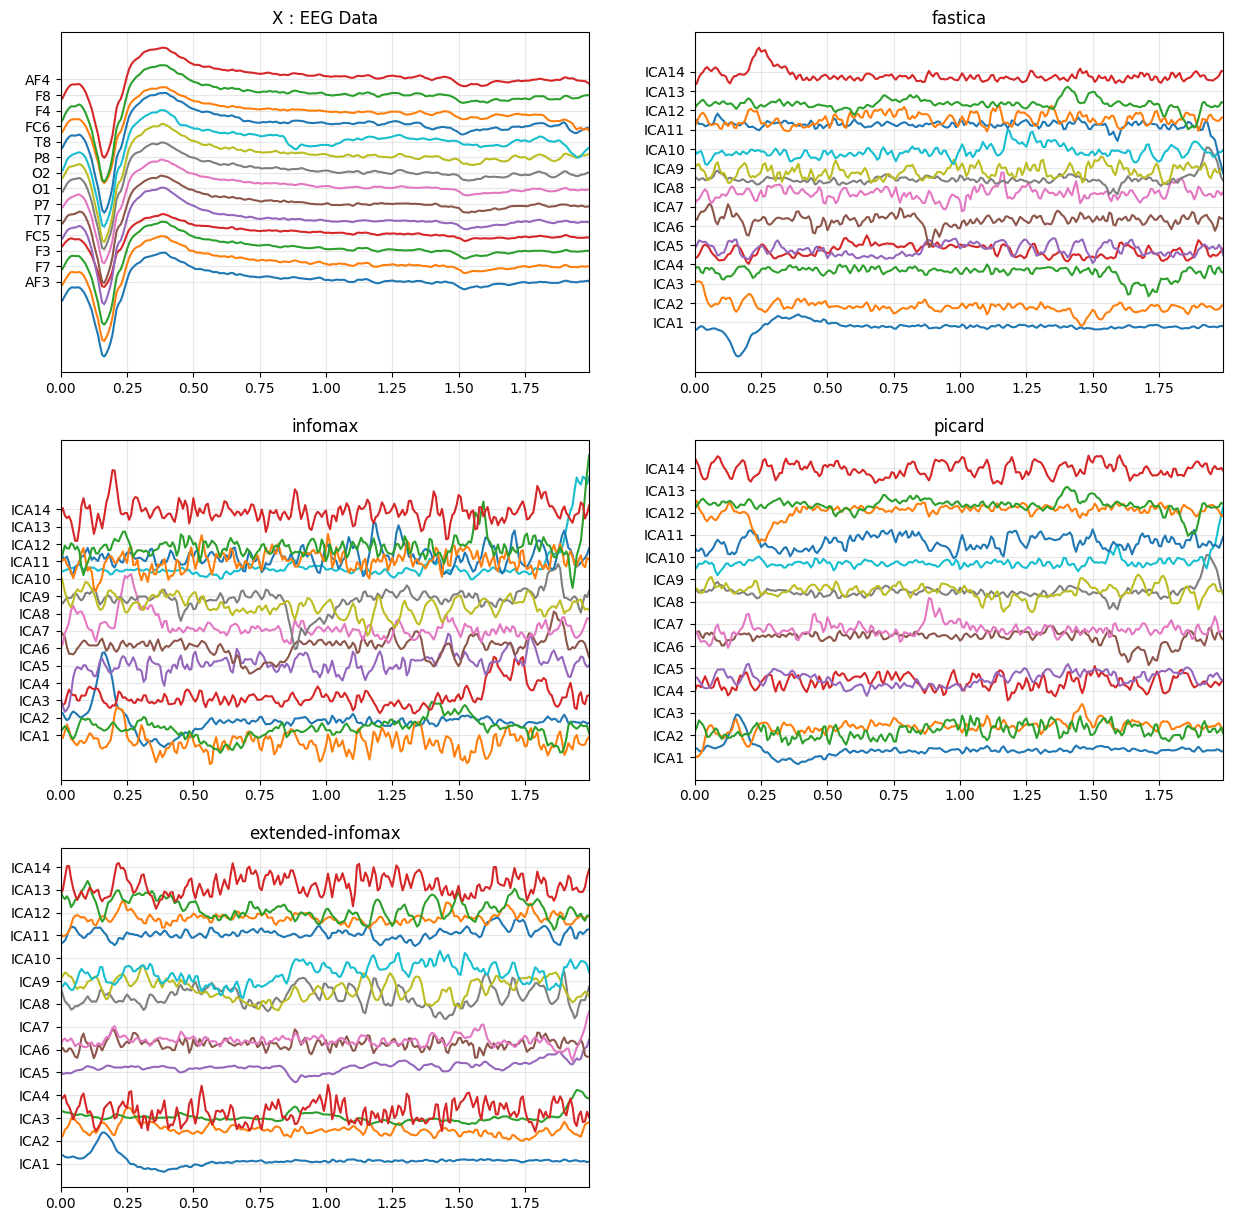

In [6]:


methods = ('fastica', 'infomax', 'picard', 'extended-infomax')
icap = ['ICA'+str(i) for i in range(1,15)]

plt.figure(figsize=(15,15))
plt.subplot(321)
plt.plot(t,x+np.arange(nC)*200)
plt.xlim([t[0],t[-1]])
plt.yticks(np.arange(nC)*200,ch_names)
plt.grid(alpha=0.3)
plt.title('X : EEG Data')

S = [s1,s2,s3,s4]
for i in range(4):
    plt.subplot(3,2,i+2)
    plt.plot(t,S[i].T+np.arange(nC)*700)
    plt.xlim([t[0],t[-1]])
    plt.yticks(np.arange(nC)*700,icap)
    plt.grid(alpha=0.3)
    plt.title(methods[i])

plt.show()

## Bird call

In [3]:
import librosa

import sys
import os

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt import cwt2, rd_file, cwt3

from IPython.display import Audio

DB_RANGE = 100 # dynamic range to show in dB
SR = 22050
CMAP = 'magma'
TRAIN_DIR = '../data/sound/cornell-birdcall/train_audio'

In [4]:
d2, sr, dura = rd_file(f'{TRAIN_DIR}/btbwar/XC51863_denoised.wav')
print(f'sr={sr}, duration={dura}')
Audio(d2, rate=sr)

data type: float32
data size should be 1691136.0
size of rd_file data: 1691136
sr=22050, duration=19.173877551020407


bird call in Morlet wavelet


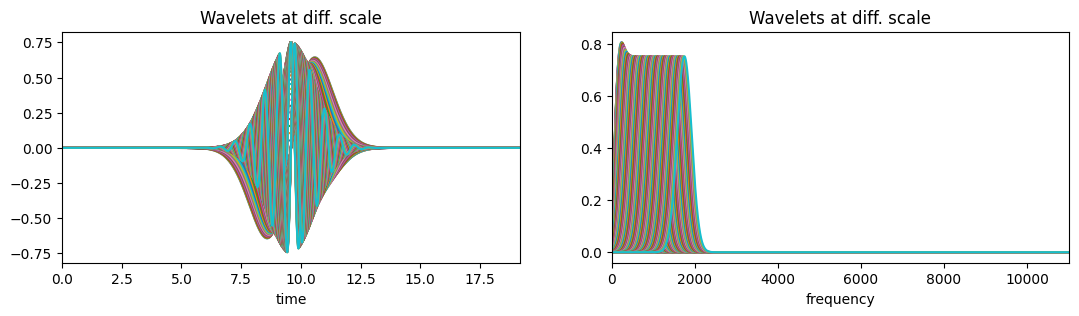

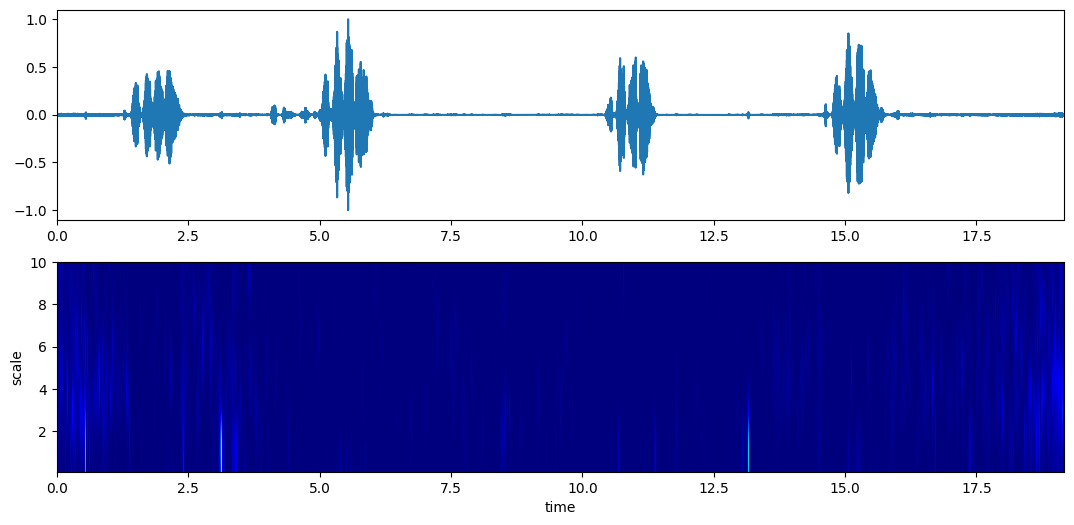

In [5]:
print('bird call in Morlet wavelet')
t = np.arange(len(d2))/sr
XW,S = ScalogramCWT(d2, t, fs=sr, wType='Morlet', PlotPSD=True, PlotW=True)

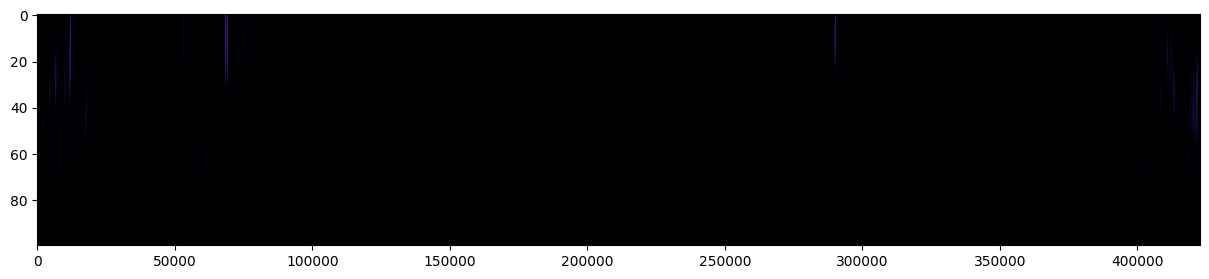

In [7]:

plt.figure(figsize=(15,3))
# plt.imshow(np.abs(XW),aspect='auto',origin='lower',cmap='jet',interpolation='sinc')
plt.imshow(20*np.log10(np.abs(XW)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-60)
plt.show()

## Documentation

In [11]:
help(ScalogramCWT)

Help on function ScalogramCWT in module spkit.core.cwt:

ScalogramCWT(x, t, wType='Gauss', fs=128, PlotPSD=False, PlotW=False, fftMeth=True, interpolation='sinc', **Parameters)
    Compute scalogram using Continues Wavelet Transform for wavelet type (wType) and given scale range
    
    Parameters
    ----------
    
    x: array-like, input signal,
    t: array-like, time array corresponding to x, same length as x
    fs: sampling rate
    PlotPSD: bool, if True, plot Scalogram
    PlotW :  bool, if True, plot wavelets in time and frequecy with different scalling version
    fftMeth: if True, FFT method is used, else convolution method is used. FFT method is faster.
    interpolation: str, or None, interpolation while ploting Scalogram.
    
    Parameters for different wavelet functions
    --------
    Common Parameters for all the Wavelet functions
    
    f : array of frequency range to be analysed, e.g. np.linspace(-10,10,2*N-1), where N = len(x)
      : if None, frequency rang